In [1]:
!pip install langchain-huggingface

In [29]:
from langgraph.graph import StateGraph,START,END
from langchain_huggingface import ChatHuggingFace,HuggingFaceEndpoint
from dotenv import load_dotenv
import os
from langgraph.graph.message import add_messages
from pydantic import BaseModel
import operator
from typing import Annotated,TypedDict
from langchain_core.messages import BaseMessage,HumanMessage


In [3]:
import os
from google.colab import userdata

# 1. Get the key from Colab Secrets
api_key = userdata.get("APIKEY")

# 2. Set it as an environment variable (Crucial step)
os.environ["HUGGINGFACEHUB_API_TOKEN"] = api_key

In [9]:
load_dotenv()

llm =HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    task="text-generation",
    huggingfacehub_api_token = os.getenv("HUGGINGFACEHUB_API_TOKEN")
)
model = ChatHuggingFace(llm = llm)

model.invoke("hey")


AIMessage(content="How's it going? Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 36, 'total_tokens': 57}, 'model_name': 'meta-llama/Llama-3.1-8B-Instruct', 'system_fingerprint': 'fp_f613d2b18eccee549c5f', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e3619-4726-76e0-80b9-7b6ba7059ca0-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 21, 'total_tokens': 57})

In [19]:
class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

In [32]:
def chatnode(state: ChatState):
    messages = state["messages"]
    response = model.invoke(messages)
    return {"messages": [response]}

In [33]:
graph = StateGraph(ChatState)

graph.add_node("chat_node",chatnode)
graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile()

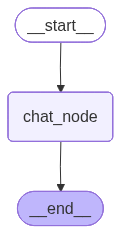

In [34]:
chatbot

In [35]:
initial_state = {
    "messages": [HumanMessage(content='What is the capital of india')]
}

chatbot.invoke(initial_state)['messages'][-1].content

'The capital of India is New Delhi.'